In [2]:
from sctoolbox.utils.jupyter import bgcolor, _compare_version

# change the background of input cells
bgcolor("PowderBlue", select=[3, 6, 9, 11])

nb_name = "annotation.ipynb"

_compare_version(nb_name)

# Cell type annotation and marker list assembly
<hr style="border:2px solid black"> </hr>

## 1 - Description

**Requires a clustered or otherwise categorized anndata object. A clustering can be generated with a clustering notebook (e.g. `rna_analysis/notebooks/04_clustering.ipynb`).**

**Move this notebook into the notebook folder (e.g. `rna_analysis/notebooks/`) of the respective analysis before using it!**

This Jupyter Notebook is designed for annotating cell types in clustered AnnData objects. It is divided into two main parts:

- **Marker List Assembly**: This part is used when no existing marker lists are available. It enables users to assemble custom marker lists using the MarkerRepo.

- **Annotation**: This section applies the created or provided marker lists to annotate cell types in AnnData objects.


For more information about MarkerRepo, click [here](https://gitlab.gwdg.de/loosolab/software/annotate_by_marker_and_features).

--------------

## 2- Setup

In [3]:
from sctoolbox import settings
import sctoolbox.utils as utils
import sctoolbox.plotting as pl
import os
import pandas as pd
pd.set_option('display.max_columns', None)  # no limit to the number of columns shown

settings.settings_from_config("config.yaml", key="annoation")

Created directory: ../figures/annotation/
Created directory: ../tables/annotation/
Created directory: ../report/annotation/


In [4]:
try:
    import markerrepo.wrappers as wrap
    import markerrepo.marker_repo as mr
except ModuleNotFoundError:
    raise ModuleNotFoundError("Please install the latest MarkerRepo version.")
    
with pd.option_context("display.max.rows", None, "display.max_colwidth", None):
    display(utils.general.get_version_report(report="versions.yml"))

/mnt/workspace2/hschult/.conda/sctoolbox/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


,Name,Version
0,Python,"3.12.12 | packaged by conda-forge | (main, Oct 22 2025, 23:25:55) [GCC 14.3.0]"
1,pandas,2.3.3
2,anndata,0.12.6
3,markerrepo,0.1
4,numpy,2.3.5
5,scanpy,1.11.5
6,sctoolbox,NA


<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [5]:
# Set inpput anndata
clustered_adata = "anndata_marker.h5ad"

___

## 3 - Loading adata

In [6]:
adata = utils.adata.load_h5ad(clustered_adata)

[INFO] The adata object was loaded from: ../adatas/anndata_marker.h5ad


In [7]:
with pd.option_context("display.max.rows", 5, "display.max.columns", None):
    display(adata)
    display(adata.obs)

AnnData object with n_obs × n_vars = 3020 × 19581
    obs: 'paper_cluster', 'filename', 'sample', 'timepoint', 'batch', 'Paper cell type', 'Spatial expression domain', 'total_counts', 'log1p_total_counts', 'total_counts_is_mito', 'log1p_total_counts_is_mito', 'pct_counts_is_mito', 'total_counts_is_ribo', 'log1p_total_counts_is_ribo', 'pct_counts_is_ribo', 'doublet_score', 'predicted_doublet', 'predicted_sex', 'n_genes', 'log1p_n_genes', 'S_score', 'G2M_score', 'phase', 'leiden', 'LISI_score_X_pca', 'LISI_score_X_umap', 'phase_density', 'sample_density', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'leiden_0.6', 'leiden_0.7', 'leiden_0.8', 'leiden_0.9', 'leiden_1.0', 'leiden_1.1', 'leiden_1.2', 'leiden_1.3', 'leiden_1.4', 'leiden_1.5', 'leiden_1.6', 'leiden_1.7', 'leiden_1.8', 'leiden_1.9', 'clustering'
    var: 'gene_id', 'is_mito', 'is_ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts',

,paper_cluster,filename,sample,timepoint,batch,Paper cell type,Spatial expression domain,total_counts,log1p_total_counts,total_counts_is_mito,log1p_total_counts_is_mito,pct_counts_is_mito,total_counts_is_ribo,log1p_total_counts_is_ribo,pct_counts_is_ribo,doublet_score,predicted_doublet,predicted_sex,n_genes,log1p_n_genes,S_score,G2M_score,phase,leiden,LISI_score_X_pca,LISI_score_X_umap,phase_density,sample_density,leiden_0.1,leiden_0.2,leiden_0.3,leiden_0.4,leiden_0.5,leiden_0.6,leiden_0.7,leiden_0.8,leiden_0.9,leiden_1.0,leiden_1.1,leiden_1.2,leiden_1.3,leiden_1.4,leiden_1.5,leiden_1.6,leiden_1.7,leiden_1.8,leiden_1.9,clustering
AAACCTGGTTCACCTC-1,2,GSM5402428_scRNAseq_Sox10_Cre_bact_BtR_1.5dpf_...,GSM5402428,1.5dpf,rep_1,Mesenchyme,Dorsal,6103.0,8.716700,72.0,4.290460,1.179748,2230.0,7.710205,36.539406,0.056507,False,Male,1755,7.470794,0.268915,0.248664,S,0,1.0,1.0,0.368713,0.574144,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
AAACCTGTCCCAAGAT-1,4,GSM5402428_scRNAseq_Sox10_Cre_bact_BtR_1.5dpf_...,GSM5402428,1.5dpf,rep_1,Neuronal,NaN,2433.0,7.797291,20.0,3.044523,0.822030,821.0,6.711740,33.744347,0.017997,False,Male,779,6.659294,-0.356754,-0.144525,G1,2,1.0,1.0,0.449944,0.094102,2,3,2,3,3,3,3,3,2,3,2,2,2,2,4,3,3,2,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCATCCGAAGAG-1,3,GSM5402428_scRNAseq_Sox10_Cre_bact_BtR_1.5dpf_...,GSM5402428,1.5dpf,rep_1,Mesenchyme,Dorsal,4168.0,8.335431,68.0,4.234107,1.631478,1867.0,7.532624,44.793667,0.043165,False,Male,1099,7.003065,-0.139991,-0.219923,G1,6,1.0,1.0,0.719973,0.818915,1,2,1,1,1,1,8,2,6,7,6,9,10,6,8,7,2,7,8,6
TTTGTCATCCTCAATT-1,7,GSM5402428_scRNAseq_Sox10_Cre_bact_BtR_1.5dpf_...,GSM5402428,1.5dpf,rep_1,Mesenchyme,Posterior,4035.0,8.303009,133.0,4.897840,3.296159,1680.0,7.427144,41.635689,0.059240,False,Male,1169,7.064759,-0.264195,0.153916,G2M,13,1.0,1.0,0.332325,0.349347,1,2,1,9,9,10,12,11,14,14,16,15,16,10,16,12,18,17,19,16


___

## 4 - Essential Input
<hr style="border:2px solid black"> </hr>
Adjust the parameters shown below to enable basic cell type annotation.

### 4.1 - Parameter Overview
<hr style="border:1px solid black"> </hr>

| Parameter | Description | Options |
|-----------|-------------|--------------|
| `clustering_column` | `.obs` column used for the cell type assignment. | `None` (select interactively) or String (e.g., `"leiden"`) |
| `organism` | Specifies the organism for marker list assembly (see `4.1.1`). None to provide a custom marker list (see `marker_lists`). | `None` or String (e.g., `"human"`) |
| `marker_lists` | Use preassembled marker lists. Either a path to a directory of marker lists, paths to marker lists or None to manually assemble one. See section `4.1.2` for details. | `None` or String or list of Strings (e.g., `"/path/my_markers"` or `["/heart_markers/markers", "/human/panglao"]` |
| `repo_path` | Path to MarkerRepo. if None, the MarkerRepo will be downloaded to the notebooks folder| `None` or String |

#### 4.1.1 Available organisms
The organism of the current dataset. Will be used to assemble a marker list based on the internally provided sources. 

Currently available organisms are:

- `human`

- `mouse`

- `zebrafish`

- `rat`
 
This parameter will be ignored in favor of a custom marker list (see section `4.1.2` below). This will also cause the assembly section (`5`) to be skipped.


#### 4.1.2 - Custom marker list
Alternatively, the user can supply a custom list of marker genes by setting `marker_lists` to a user-supplied file. This has to be a **delimited text file (`.csv`, `.tsv`, ...), without a header and with two columns**. The first column contains the marker names and the second column has the cell types. For example:
```
marker_1    Fibroblast
marker_2    Fibroblast
marker_3    Endocardium
...
```

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [8]:
# Annotation settings
clustering_column = "leiden_1.1"
organism = "zebrafish"
# set path to custom marker lists
marker_lists = None

# add the path to annotate_by_marker_and_features repo
# set to None to clone the repository to your notebooks folder
repo_path = None

# Data layer (advanced)
# decide which processing state of the data should be used for computation
# available layers can be seen above, e.g. "norm" to use normalized data
# it is recommended to use raw or normalized data for statistical testing
layer = None

In [9]:
# check path of MarkerRepo
if repo_path is None or not os.path.exists(repo_path):
    if not os.path.exists("./annotate_by_marker_and_features"):
        print("MarkerRepo was not found! Cloning repository...")
        !git clone https://gitlab.gwdg.de/loosolab/software/annotate_by_marker_and_features.git
    else:
        print("MarkerRepo was found! Changing path to <./annotate_by_marker_and_features>")
    repo_path = "./annotate_by_marker_and_features"

MarkerRepo was not found! Cloning repository...
Cloning into 'annotate_by_marker_and_features'...
remote: Enumerating objects: 2433, done.
remote: Counting objects: 100% (102/102), done.
remote: Compressing objects: 100% (101/101), done.
remote: Total 2433 (delta 54), reused 0 (delta 0), pack-reused 2331 (from 1)
Receiving objects: 100% (2433/2433), 73.79 MiB | 4.41 MiB/s, done.
Resolving deltas: 100% (1523/1523), done.


--------------

## 5 - Marker List Assembly
<hr style="border:2px solid black"> </hr>

The marker list paths are stored in the <b>marker_lists</b> variable. They work as input for the actual cell type annotation of the next cell.

### 5.1 - Parameter Overview
<hr style="border:1px solid black"> </hr>

| Parameter | Description | Options |
|-----------|-------------|---------|
| `search_terms` | Search terms for the marker list assembly, targeting specific columns. | `None` or Dictionary (e.g., `{"Source": "panglao.se", "Tissue", "Heart"}`) |
| `list_format` | Additional parameters for marker list assembly. One marker list is created per dictionary. | `None` or List of dictionaries (e.g., `[{"style":"two_column", "file_name":"two_column"}, {"style":"score", "file_name":"score"}]`|

**Recommendation:** Set `search_terms` and `list_format` to `None` this enables an interactive guide to assemble the marker list. Manually setting `search_terms` and `list_format` is mostly intended for advanced users who already know what to search for.

#### 5.1.1 search_terms (advanced)
Each `key:value` pair will narrow the search in the marker list database to target specific lists, for example, setting `"Organism name": "human"` will ensure the use of marker lists relevant to the selected organism. Multiple search terms will be connected with a logical `AND` e.g. `"Organism name": "human", "Tissue": "blood"` will only consider human marker genes of blood during list assembly.

**Run the following cell to see available input(s) for `search_terms`.**

#### 5.1.2 list_format (advanced)
The `list_format` parameter decides the method and format of the resulting annotation list. Each dictionary entry will result in a marker list, which will be saved locally as a separate annotation list.

| Key | Value | Description |
|-----|-------|-------------|
| `file_name` | `None` or filename | The file where the finished list will be stored. Set `None` or skip entry to set the name interactively. |
| `style` | One of `two_column`, `score` or `ui` | The style of the marker lists. Either a minimal list of gene to cell type assignments (`two_column`), a list including a score (average count of a marker gene across all lists, to measure specificity of markers to a cell type) (`score`) or a list where each gene is weighted by the ubiquitousness index (see below). |

>[The] **ubiquitousness index** (UI), [...] is an indicator of how often the gene is expressed in cell clusters. UI takes values between 0 and 1. Values toward 1 indicate the gene is expressed in more cell clusters, indicating the gene to be involved in housekeeping tasks.

[Franzén et al., 2019](https://doi.org/10.1093/database/baz046)

**List of available inputs for `search_terms`**

In [10]:
if not marker_lists and not organism:
    raise ValueError("Please provide either <organism> or a path to custom marker list <marker_lists>")
if not marker_lists:
    df = mr.search_df(df=mr.combine_dfs(repo_path=repo_path), col_to_search="Organism name", search_terms=[f"+{organism.split(' ')[0]}"])
    print(f"* Possible keys for <column_specific_terms>:\n {df.columns.to_list()}\n")
    for col in df.columns[:12]:
        print(f"* Possible values for {col}: {df[col].dropna().drop_duplicates().to_list()}\n")

* Possible keys for <column_specific_terms>:
 ['List name', 'Marker type', 'Organism name', 'Taxonomy ID', 'Submitter name', 'List type', 'Source', 'tags_transferred', 'Date', 'Email', 'Tissue', 'tags_info', 'Life stage', 'tags_age', 'Marker', 'Info']

* Possible values for List name: ['Zebrafish_mito', 'zebrafish_embryo', 'zebrafish_embryo2', 'zebrafish_brain', 'zebrafish_eye', 'zebrafish_heart', 'zebrafish_pancreas_intestine', 'zebrafish_kidney', 'zebrafish_liver', 'zebrafish_muscle', 'zebrafish_ovary', 'zebrafish_skin', 'zebrafish_spleen', 'zebrafish_bladder', 'zebrafish_testis', 'zebrafish_cord_blood', 'zebrafish_lung', 'zebrafish_cellcycle_genes', 'zebrafish_mito_genes', 'zebrafish_cranial_neural_crest_150dpf', 'zebrafish_cranial_neural_crest_1.5dpf', 'zebrafish_cranial_neural_crest_14dpf', 'zebrafish_non_cranial_neural_crest', 'zebrafish_non_mesenchymal_cranial_neural_crest', 'heart_tarasco']

* Possible values for Marker type: ['Genes']

* Possible values for Organism name: ['ze

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [11]:
# Marker list assembly
if not marker_lists:
    # we recommend specifying "Tissue" if possible to get more accurate results
    search_terms = {"Organism name": organism, 
                    "List name": ["zebrafish_cranial_neural_crest_14dpf",
                                  "zebrafish_non_cranial_neural_crest",
                                  "zebrafish_non_mesenchymal_cranial_neural_crest"]
                   }

    list_format = [{"file_name":"symbol", "style":"two_column"},
                   {"file_name":"score", "style":"score"},
                   {"file_name":"ui", "style":"ui"}
                  ]

___

In [12]:
if not marker_lists:
    marker_lists = wrap.create_multiple_marker_lists(
        cml_parameters=list_format,
        repo_path=repo_path,
        organism=organism,
        ensembl=mr.check_ensembl(adata),
        column_specific_terms=search_terms,
        show_lists=True,
        path=settings.table_dir
    )

Found 25 marker lists for the given organism zebrafish.


,List name,Marker type,Organism name,Taxonomy ID,Submitter name,List type,Source,tags_transferred,Date,Email,Tissue,tags_info,Life stage,tags_age,Marker,Info
ID,,,,,,,,,,,,,,,,
1688745542877159,Zebrafish_mito,Genes,zebrafish,7955,"Kessler, Micha Frederick",Mitochondrial,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[MT-CO2, ENSDARG00000063908, MT-ND6, ENSDARG00...",[mito]
1704948866343881,zebrafish_embryo,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,NaN,NaN,embryo,NaN,"[PVALB3, ENSDARG00000022817, SI:CH73-359M17.5,...","[Mesenchymal cell, Macrophage, Neuroblast, Len..."
1704949706689035,zebrafish_embryo2,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,NaN,NaN,embryo,NaN,"[BRD3B, ENSDARG00000100129, SI:CH73-86N18.1, E...","[Hatching gland_he1.2 high, Macrophage, Neuron..."
1704950385309273,zebrafish_brain,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,brain,NaN,NaN,NaN,"[TNFRSF9A, ENSDARG00000060498, CD59, ENSDARG00...","[Oligodendrocyte, Radial glia, Macrophage, Neu..."
1704950859567107,zebrafish_eye,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,eye,NaN,NaN,NaN,"[CD59, ENSDARG00000090615, PFN1, ENSDARG000000...","[Stromal cell, Retinal rod cell, Mt_rich cell,..."
1704951711968568,zebrafish_heart,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,heart,NaN,NaN,NaN,"[CD59, ENSDARG00000090615, FEN1, ENSDARG000000...","[Mt_rich cell, Proliferating cell, Cardiomyocy..."
1704951902892390,zebrafish_pancreas_intestine,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,pancreas\nintestine,NaN,NaN,NaN,"[SI:CH73-359M17.5, ENSDARG00000101088, CD59, E...","[Immunocyte, Enterocyte_rbp2b high, Intestinal..."
1704952096274898,zebrafish_kidney,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,kidney,NaN,NaN,NaN,"[SI:CH73-359M17.5, ENSDARG00000101088, CD59, E...","[Proliferating cell, Nephron epithelial cell, ..."
1704952524756597,zebrafish_liver,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,liver,NaN,NaN,NaN,"[FAM49A, ENSDARG00000006672, PFN1, ENSDARG0000...","[Erythrocyte, Endothelial cell, Biliary epithe..."


Found 3 marker lists for the given search terms.


,List name,Marker type,Organism name,Taxonomy ID,Submitter name,List type,Source,tags_transferred,Date,Email,Tissue,tags_info,Life stage,tags_age,Marker,Info
ID,,,,,,,,,,,,,,,,
1741686677329305,zebrafish_cranial_neural_crest_14dpf,Genes,zebrafish,7955,"Schultheis, Hendrik",Cell type annotation,https://doi.org/10.1038/s41467-021-27594-w,NaN,NaN,hendrik.schultheis@mpi-bn.mpg.de,cranial neural crest,NaN,child,14 dpf,"[ACTA2, ENSDARG00000045180, FGF10B, ENSDARG000...","[Gill cartilage, Gill progenitor, Perichondriu..."
1741687334852231,zebrafish_non_cranial_neural_crest,Genes,zebrafish,7955,"Schultheis, Hendrik",Cell type annotation,https://doi.org/10.1038/s41467-021-27594-w,NaN,NaN,hendrik.schultheis@mpi-bn.mpg.de,cranial neural crest,non cranial neural crest,NaN,NaN,"[EPCAM, ENSDARG00000040534, HBBE2, ENSDARG0000...","[Epithelia, Blood]"
1741687684295404,zebrafish_non_mesenchymal_cranial_neural_crest,Genes,zebrafish,7955,"Schultheis, Hendrik",Cell type annotation,https://doi.org/10.1038/s41467-021-27594-w,NaN,NaN,hendrik.schultheis@mpi-bn.mpg.de,cranial neural crest,non-mesenchymal cranial neural crest derivatives,NaN,NaN,"[ZWI, ENSDARG00000101826, MITFA, ENSDARG000000...","[Iridophores, Neuronal, Glia, Melanocytes, Oti..."


Preparing two column style marker list...
Marker list saved: /mnt/workspace2/hschult/sc-framework-paper/Code_Schultheis_et_al_2025_SC-Framework/RNA/analysis/01-1.5dpf/tables/annotation/symbol
Found 25 marker lists for the given organism zebrafish.


...

Preparing score style marker list...
Marker list saved: /mnt/workspace2/hschult/sc-framework-paper/Code_Schultheis_et_al_2025_SC-Framework/RNA/analysis/01-1.5dpf/tables/annotation/score
Found 25 marker lists for the given organism zebrafish.


,List name,Marker type,Organism name,Taxonomy ID,Submitter name,List type,Source,tags_transferred,Date,Email,Tissue,tags_info,Life stage,tags_age,Marker,Info
ID,,,,,,,,,,,,,,,,
1688745542877159,Zebrafish_mito,Genes,zebrafish,7955,"Kessler, Micha Frederick",Mitochondrial,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[MT-CO2, ENSDARG00000063908, MT-ND6, ENSDARG00...",[mito]
1704948866343881,zebrafish_embryo,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,NaN,NaN,embryo,NaN,"[PVALB3, ENSDARG00000022817, SI:CH73-359M17.5,...","[Mesenchymal cell, Macrophage, Neuroblast, Len..."
1704949706689035,zebrafish_embryo2,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,NaN,NaN,embryo,NaN,"[BRD3B, ENSDARG00000100129, SI:CH73-86N18.1, E...","[Hatching gland_he1.2 high, Macrophage, Neuron..."
1704950385309273,zebrafish_brain,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,brain,NaN,NaN,NaN,"[TNFRSF9A, ENSDARG00000060498, CD59, ENSDARG00...","[Oligodendrocyte, Radial glia, Macrophage, Neu..."
1704950859567107,zebrafish_eye,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,eye,NaN,NaN,NaN,"[CD59, ENSDARG00000090615, PFN1, ENSDARG000000...","[Stromal cell, Retinal rod cell, Mt_rich cell,..."
1704951711968568,zebrafish_heart,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,heart,NaN,NaN,NaN,"[CD59, ENSDARG00000090615, FEN1, ENSDARG000000...","[Mt_rich cell, Proliferating cell, Cardiomyocy..."
1704951902892390,zebrafish_pancreas_intestine,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,pancreas\nintestine,NaN,NaN,NaN,"[SI:CH73-359M17.5, ENSDARG00000101088, CD59, E...","[Immunocyte, Enterocyte_rbp2b high, Intestinal..."
1704952096274898,zebrafish_kidney,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,kidney,NaN,NaN,NaN,"[SI:CH73-359M17.5, ENSDARG00000101088, CD59, E...","[Proliferating cell, Nephron epithelial cell, ..."
1704952524756597,zebrafish_liver,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,liver,NaN,NaN,NaN,"[FAM49A, ENSDARG00000006672, PFN1, ENSDARG0000...","[Erythrocyte, Endothelial cell, Biliary epithe..."


Found 3 marker lists for the given search terms.


,List name,Marker type,Organism name,Taxonomy ID,Submitter name,List type,Source,tags_transferred,Date,Email,Tissue,tags_info,Life stage,tags_age,Marker,Info
ID,,,,,,,,,,,,,,,,
1741686677329305,zebrafish_cranial_neural_crest_14dpf,Genes,zebrafish,7955,"Schultheis, Hendrik",Cell type annotation,https://doi.org/10.1038/s41467-021-27594-w,NaN,NaN,hendrik.schultheis@mpi-bn.mpg.de,cranial neural crest,NaN,child,14 dpf,"[ACTA2, ENSDARG00000045180, FGF10B, ENSDARG000...","[Gill cartilage, Gill progenitor, Perichondriu..."
1741687334852231,zebrafish_non_cranial_neural_crest,Genes,zebrafish,7955,"Schultheis, Hendrik",Cell type annotation,https://doi.org/10.1038/s41467-021-27594-w,NaN,NaN,hendrik.schultheis@mpi-bn.mpg.de,cranial neural crest,non cranial neural crest,NaN,NaN,"[EPCAM, ENSDARG00000040534, HBBE2, ENSDARG0000...","[Epithelia, Blood]"
1741687684295404,zebrafish_non_mesenchymal_cranial_neural_crest,Genes,zebrafish,7955,"Schultheis, Hendrik",Cell type annotation,https://doi.org/10.1038/s41467-021-27594-w,NaN,NaN,hendrik.schultheis@mpi-bn.mpg.de,cranial neural crest,non-mesenchymal cranial neural crest derivatives,NaN,NaN,"[ZWI, ENSDARG00000101826, MITFA, ENSDARG000000...","[Iridophores, Neuronal, Glia, Melanocytes, Oti..."


Preparing ui style marker list...
Directory does not exist. Cloning the whitelist repository...
Repository cloned.
Marker list saved: /mnt/workspace2/hschult/sc-framework-paper/Code_Schultheis_et_al_2025_SC-Framework/RNA/analysis/01-1.5dpf/tables/annotation/ui


--------------

## 6 - Annotate adata
<hr style="border:2px solid black"> </hr>
After selection and creation of the gene marker lists, potential cell types can be annotated in this final step. This notebook supports two methods of annotation, MarkerRepo and SCSA.

### 6.1 - Parameter Overview

| Parameter | Description | Options/Type |
|-----------|-------------|--------------|
| `marker_repo` | Use [MarkerRepo](https://gitlab.gwdg.de/loosolab/software/annotate_by_marker_and_features) for annotation. | Boolean |
| `SCSA` | Use [SCSA](https://github.com/bioinfo-ibms-pumc/SCSA) for annotation. | Boolean |
| `mr_obs` | Prefix of the MarkerRepo annotation columns added to `anndata.obs`. | String (e.g., "mr") |
| `scsa_obs` | Prefix of the SCSA annotation columns added to `anndata.obs`. | String (e.g., "scsa") |
| `rank_genes_column` | **Advanced users only** Column of `.uns` table with rank genes scores. If `None`, the ranking will be performed on the clustering_column. | `None` or String |
| `reference_obs` | A reference annotation in `.obs` for comparison. See section `3 - Loading adata` for possible values. | `None` or String |
| `min_hits` | The minimum number of marker matches needed to annotate a cluster. May be lowered in case of small marker lists. | Integer |

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [13]:
marker_repo = True
SCSA = True
mr_obs = "MR"
scsa_obs = "SCSA"
rank_genes_column = None
reference_obs = "Paper cell type"
min_hits = 1

___

In [14]:
compare_df = wrap.run_annotation(adata,
                                 marker_repo=marker_repo,
                                 SCSA=SCSA,
                                 marker_lists=marker_lists,
                                 mr_obs=mr_obs,
                                 scsa_obs=scsa_obs,
                                 rank_genes_column=rank_genes_column,
                                 clustering_column=clustering_column,
                                 reference_obs=reference_obs,
                                 show_comparison=True,
                                 ignore_overwrite=True,
                                 show_plots=False,
                                 output_path=settings.table_dir,
                                 min_hits=min_hits
                                )
_ = pl.general.plot_table(compare_df, crop=None, report='01_Comparison_of_cell_type_annotations.png', col_width=7)

Comparison of cell type annotations:


,Paper cell type,MR_symbol_leiden_1.1,SCSA_symbol_leiden_1.1,MR_score_leiden_1.1,SCSA_score_leiden_1.1,MR_ui_leiden_1.1,SCSA_ui_leiden_1.1
leiden_1.1,,,,,,,
1,Mesenchyme,Periosteum,Mesenchyme,Periosteum,Mesenchyme,Periosteum,Mesenchyme
2,Neuronal,Hyaline cartilage,Hyaline cartilage,Hyaline cartilage,Hyaline cartilage,Hyaline cartilage,Hyaline cartilage
3,Otic cells,Neuronal,Neuronal,Neuronal,Neuronal,Neuronal,Neuronal
4,Glia,Glia,Iridophores,Glia,Iridophores,Glia,Iridophores
5,Neuronal,Neuronal,Neuronal,Neuronal,Neuronal,Neuronal,Neuronal
6,Cycling cells,Melanocytes,None,Periosteum,None,Melanocytes,None
7,Mesenchyme,Mesenchyme,None,Mesenchyme,None,Mesenchyme,None
8,Mesenchyme,Mesenchyme,None,Mesenchyme,None,Mesenchyme,None
9,Mesenchyme,Periosteum,Stroma,Periosteum,Stroma,Periosteum,Stroma


[INFO] Saving figure to ../figures/annotation/marker_genes_dots_leiden_1.1.pdf


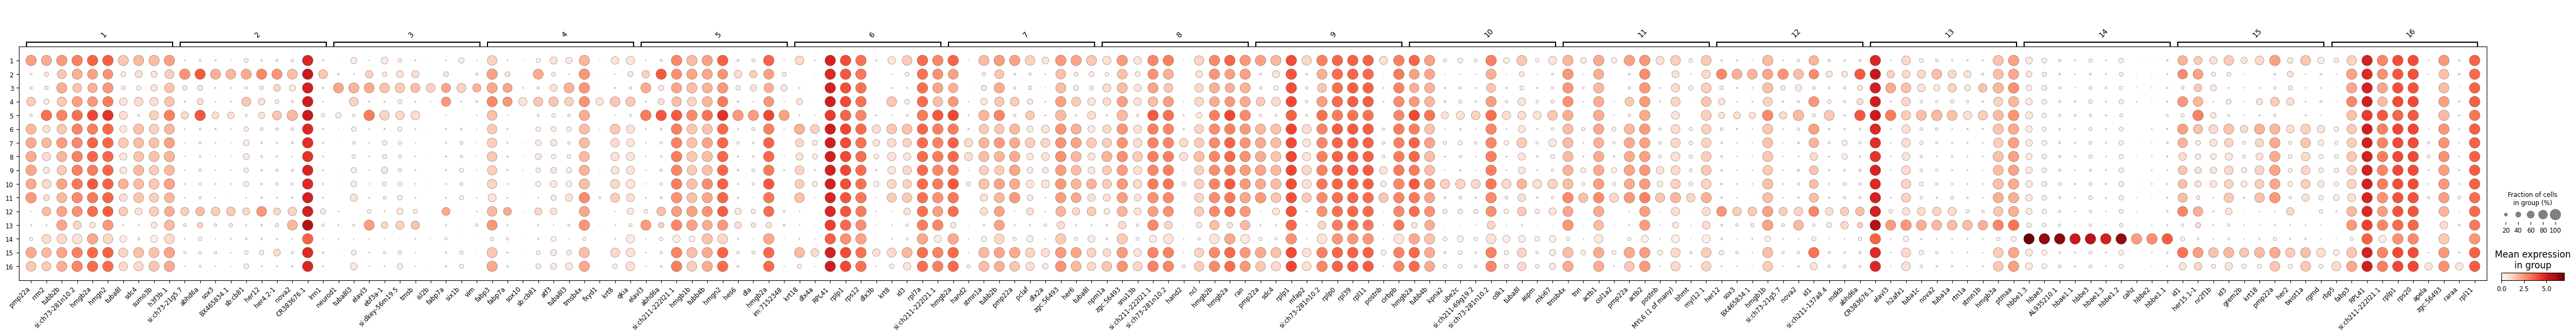

In [15]:
if not rank_genes_column:
    rank_genes_column = f"rank_genes_groups_{clustering_column}"

# Plot dotplot of markers
_ = pl.marker_genes.rank_genes_plot(
    adata,
    key=rank_genes_column,
    n_genes=10,
    style="dots",
    save=f"marker_genes_dots_{clustering_column}.pdf",
    layer=layer,
    report=f"01_marker_genes_dots_{clustering_column}.png"
)

[INFO] Saving figure to ../figures/annotation/compare_annotations.pdf


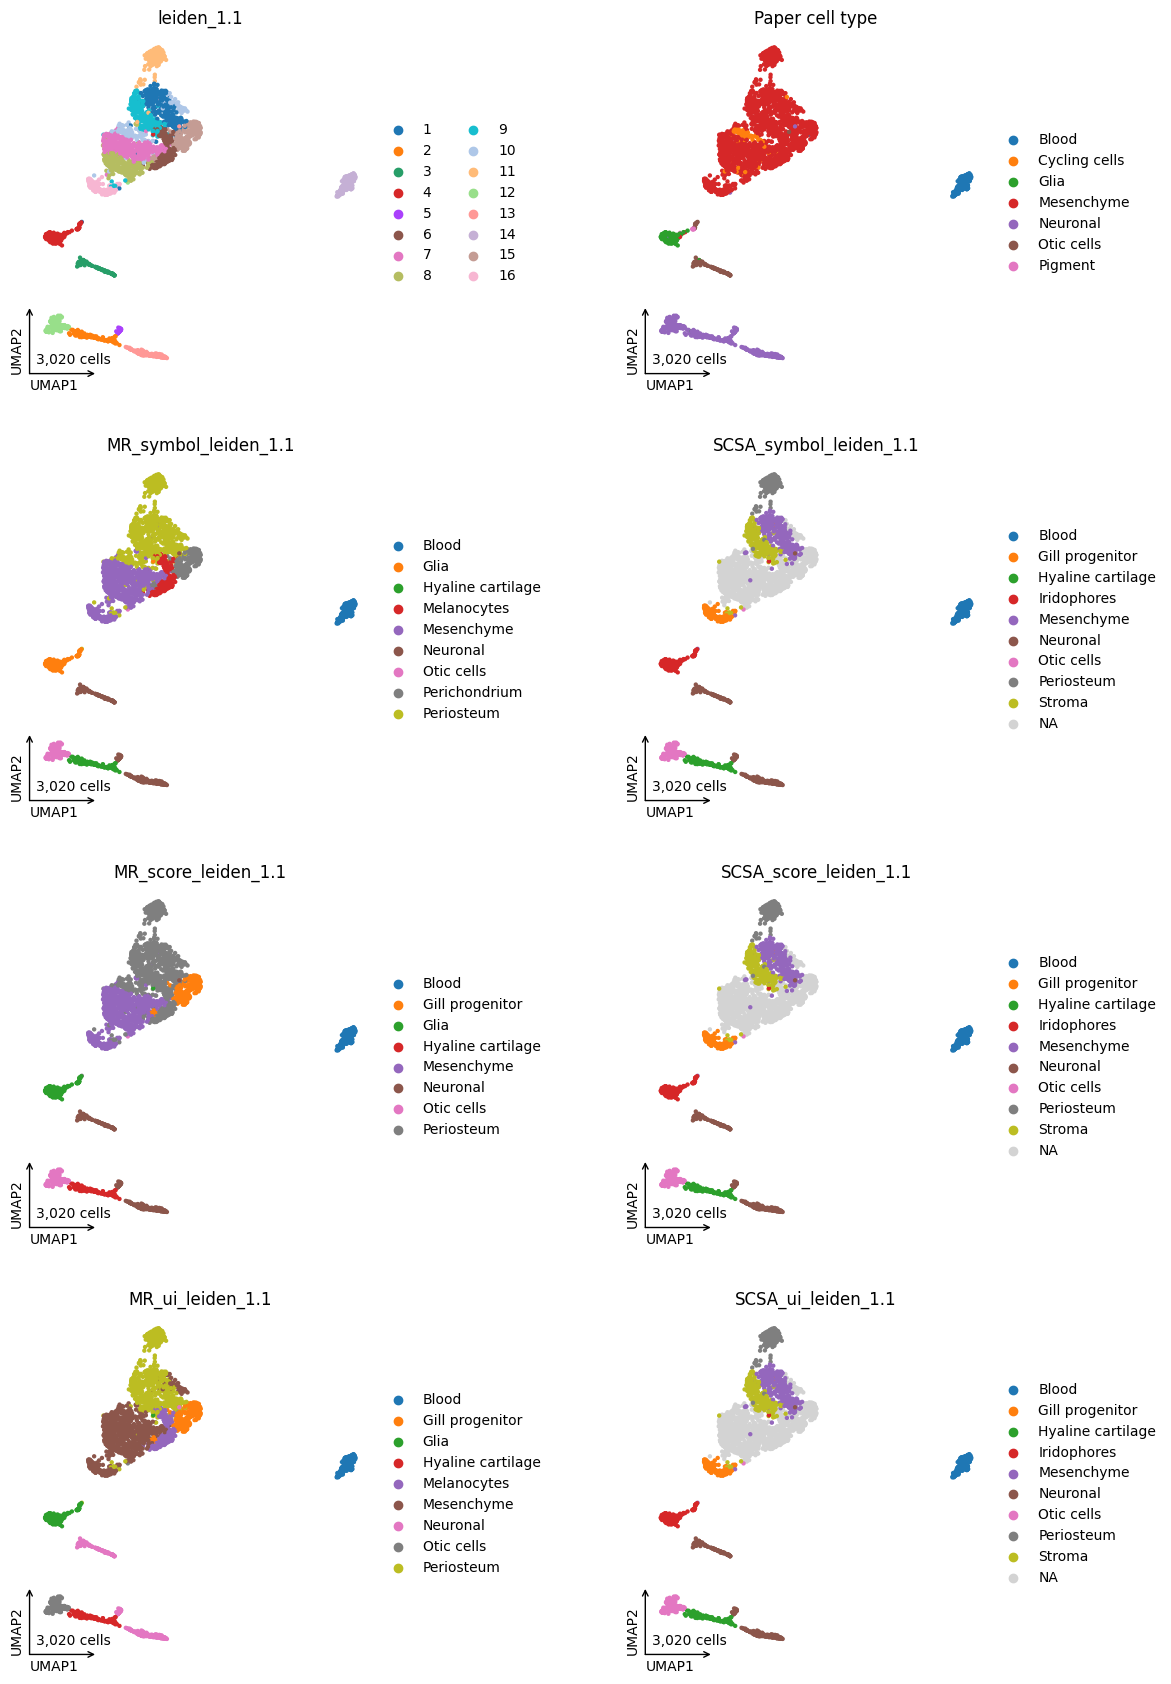

In [16]:
# Plot cell type annotations
columns = [clustering_column] + list(compare_df.columns)
_ = pl.embedding.plot_embedding(adata, method="umap", color=columns, ncols=2,
                                save="compare_annotations.pdf", report="02_compare_annotations.png")

--------------

### 6.1 - Show annotated .obs table

In [17]:
display(adata.obs)

,paper_cluster,filename,sample,timepoint,batch,Paper cell type,Spatial expression domain,total_counts,log1p_total_counts,total_counts_is_mito,log1p_total_counts_is_mito,pct_counts_is_mito,total_counts_is_ribo,log1p_total_counts_is_ribo,pct_counts_is_ribo,doublet_score,predicted_doublet,predicted_sex,n_genes,log1p_n_genes,S_score,G2M_score,phase,leiden,LISI_score_X_pca,LISI_score_X_umap,phase_density,sample_density,leiden_0.1,leiden_0.2,leiden_0.3,leiden_0.4,leiden_0.5,leiden_0.6,leiden_0.7,leiden_0.8,leiden_0.9,leiden_1.0,leiden_1.1,leiden_1.2,leiden_1.3,leiden_1.4,leiden_1.5,leiden_1.6,leiden_1.7,leiden_1.8,leiden_1.9,clustering,MR_symbol_leiden_1.1,SCSA_symbol_leiden_1.1,MR_score_leiden_1.1,SCSA_score_leiden_1.1,MR_ui_leiden_1.1,SCSA_ui_leiden_1.1
AAACCTGGTTCACCTC-1,2,GSM5402428_scRNAseq_Sox10_Cre_bact_BtR_1.5dpf_...,GSM5402428,1.5dpf,rep_1,Mesenchyme,Dorsal,6103.0,8.716700,72.0,4.290460,1.179748,2230.0,7.710205,36.539406,0.056507,False,Male,1755,7.470794,0.268915,0.248664,S,0,1.0,1.0,0.368713,0.574144,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,Periosteum,Mesenchyme,Periosteum,Mesenchyme,Periosteum,Mesenchyme
AAACCTGTCCCAAGAT-1,4,GSM5402428_scRNAseq_Sox10_Cre_bact_BtR_1.5dpf_...,GSM5402428,1.5dpf,rep_1,Neuronal,NaN,2433.0,7.797291,20.0,3.044523,0.822030,821.0,6.711740,33.744347,0.017997,False,Male,779,6.659294,-0.356754,-0.144525,G1,2,1.0,1.0,0.449944,0.094102,2,3,2,3,3,3,3,3,2,3,2,2,2,2,4,3,3,2,3,2,Hyaline cartilage,Hyaline cartilage,Hyaline cartilage,Hyaline cartilage,Hyaline cartilage,Hyaline cartilage
AAACCTGTCTCTAAGG-1,13,GSM5402428_scRNAseq_Sox10_Cre_bact_BtR_1.5dpf_...,GSM5402428,1.5dpf,rep_1,Otic cells,NaN,4500.0,8.412055,61.0,4.127134,1.355556,1730.0,7.456455,38.444443,0.068627,False,Male,1360,7.215975,0.381624,0.019581,S,3,1.0,1.0,0.020998,0.051109,3,5,3,4,4,4,4,4,4,4,3,3,3,3,5,4,4,3,4,3,Neuronal,Neuronal,Neuronal,Neuronal,Neuronal,Neuronal
AAACGGGAGGCTATCT-1,13,GSM5402428_scRNAseq_Sox10_Cre_bact_BtR_1.5dpf_...,GSM5402428,1.5dpf,rep_1,Otic cells,NaN,4260.0,8.357259,56.0,4.043051,1.314554,1670.0,7.421177,39.201878,0.041345,False,Male,1264,7.142827,-0.335436,-0.387612,G1,3,1.0,1.0,0.395728,0.052606,3,5,3,4,4,4,4,4,4,4,3,3,3,3,5,4,5,4,5,3,Neuronal,Neuronal,Neuronal,Neuronal,Neuronal,Neuronal
AAACGGGAGTTACGGG-1,12,GSM5402428_scRNAseq_Sox10_Cre_bact_BtR_1.5dpf_...,GSM5402428,1.5dpf,rep_1,Glia,NaN,2601.0,7.864036,25.0,3.258096,0.961169,918.0,6.823286,35.294117,0.026172,False,Male,981,6.889591,0.111057,-0.330096,S,4,1.0,1.0,0.049940,0.151071,3,5,4,5,5,5,5,5,5,5,4,4,4,4,6,5,6,5,6,4,Glia,Iridophores,Glia,Iridophores,Glia,Iridophores
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAAGATGGGTC-1,8,GSM5402428_scRNAseq_Sox10_Cre_bact_BtR_1.5dpf_...,GSM5402428,1.5dpf,rep_1,Mesenchyme,Frontonasal,7068.0,8.863474,121.0,4.804021,1.711941,2461.0,7.808729,34.818901,0.016510,False,Male,1904,7.552237,-0.136336,0.245931,G2M,9,1.0,1.0,0.243832,0.346204,1,1,6,7,6,7,9,7,9,10,11,11,11,12,11,13,13,11,15,11,Periosteum,Periosteum,Periosteum,Periosteum,Periosteum,Periosteum
TTTGTCAAGGCCCTCA-1,1,GSM5402428_scRNAseq_Sox10_Cre_bact_BtR_1.5dpf_...,GSM5402428,1.5dpf,rep_1,Mesenchyme,Ventral,2943.0,7.987525,47.0,3.871201,1.597010,1077.0,6.982863,36.595310,0.043165,False,Male,1074,6.980076,0.327502,-0.046174,S,7,1.0,1.0,0.436353,0.534595,1,2,1,2,2,6,2,6,10,8,7,8,7,7,2,8,9,9,9,7,Mesenchyme,NaN,Mesenchyme,NaN,Mesenchyme,NaN
TTTGTCAGTACTCTCC-1,9,GSM5402428_scRNAseq_Sox10_Cre_bact_BtR_1.5dpf_...,GSM5402428,1.5dpf,rep_1,Blood,NaN,12444.0,9.429074,68.0,4.234107,0.546448,1573.0,7.361375,12.640630,0.025120,False,Male,1084,6.989335,-0.241012,-0.158639,G1,12,1.0,1.0,0.116825,0.195537,4,6,7,8,8,9,11,10,13,13,14,14,15,16,15,17,17,16,18,14,Blood,Blood,Blood,Blood,Blood,Blood
TTTGTCATCCGAAGAG-1,3,GSM5402428_scRNAseq_Sox10_Cre_bact_BtR_1.5dpf_...,GSM5402428,1.5dpf,rep_1,Mesenchyme,Dorsal,4168.0,

In [18]:
# compare annotations to paper
paper_markers = {
    'Blood': ['hbbe2'],
    'Cycling cells': ['mcm4', 'mcm2'],
    'Glia': ['zwi'],
    'Mesenchyme': ['alx4a', 'msx1b', 'prrx1b'],
    'Neuronal': ['neurod1', 'neurod2', 'neurod4', 'neurod6a', 'neurod6b', 'stmn1b'],
    'Otic cells': ['atoh1a'],
    'Pigment': ['mitfa', 'tfec']} # melanocytes

[INFO] Saving figure to ../figures/annotation/marker_repo_score_annotation_vs_paper_markers_dotplot.png


{'mainplot_ax': <Axes: >,
 'gene_group_ax': <Axes: >,
 'size_legend_ax': <Axes: title={'center': 'Fraction of cells\nin group (%)'}>,
 'color_legend_ax': <Axes: title={'center': 'Mean expression\nin group'}>}

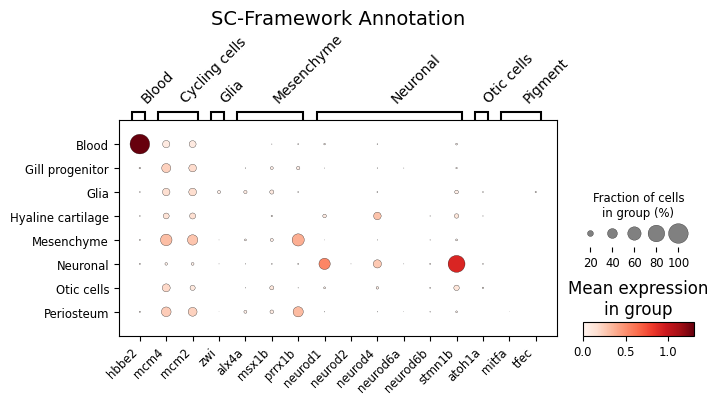

In [19]:
pl.marker_genes.rank_genes_plot(
    adata=adata,
    groupby="MR_score_leiden_1.1",
    genes=paper_markers,
    log=True,
    title="SC-Framework Annotation",
    save="marker_repo_score_annotation_vs_paper_markers_dotplot.png"
)

[INFO] Saving figure to ../figures/annotation/fabian_et_al_annotation_vs_paper_markers_dotplot.png


{'mainplot_ax': <Axes: >,
 'gene_group_ax': <Axes: >,
 'size_legend_ax': <Axes: title={'center': 'Fraction of cells\nin group (%)'}>,
 'color_legend_ax': <Axes: title={'center': 'Mean expression\nin group'}>}

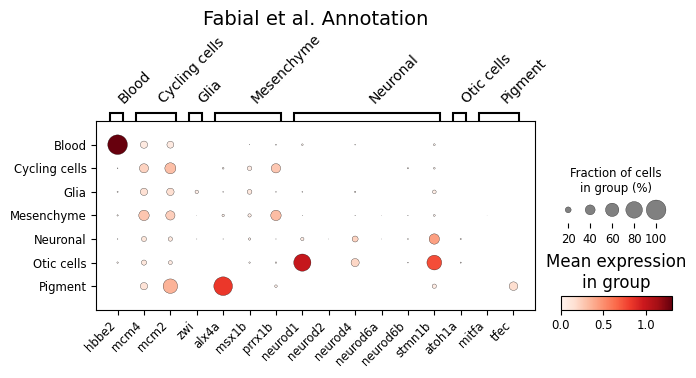

In [20]:
pl.marker_genes.rank_genes_plot(
    adata=adata,
    groupby="Paper cell type",
    genes=paper_markers,
    log=True,
    title="Fabial et al. Annotation",
    save="fabian_et_al_annotation_vs_paper_markers_dotplot.png"
)

[INFO] Saving figure to ../figures/annotation/leiden_1_1_vs_paper_markers_dotplot.png


{'mainplot_ax': <Axes: >,
 'gene_group_ax': <Axes: >,
 'size_legend_ax': <Axes: title={'center': 'Fraction of cells\nin group (%)'}>,
 'color_legend_ax': <Axes: title={'center': 'Mean expression\nin group'}>}

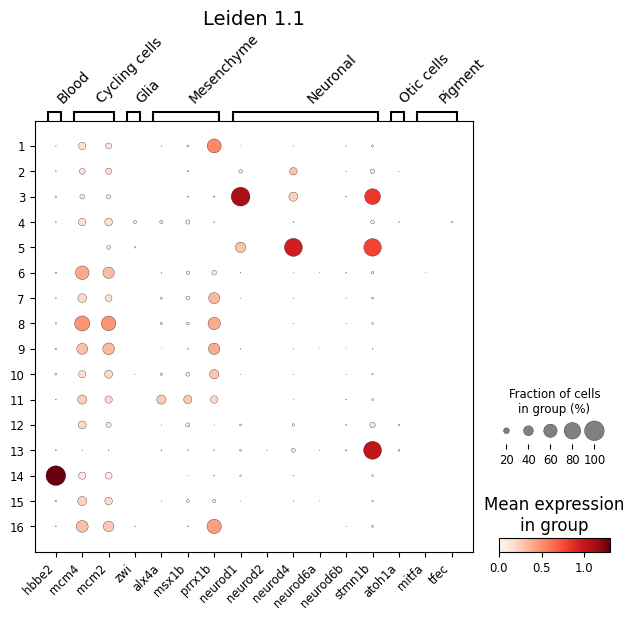

In [21]:
pl.marker_genes.rank_genes_plot(
    adata=adata,
    groupby="leiden_1.1",
    genes=paper_markers,
    log=True,
    title="Leiden 1.1",
    save="leiden_1_1_vs_paper_markers_dotplot.png"
)

--------------

## 7 - Save adata

In [22]:
utils.io.update_yaml({"annotation": True}, "method.yml", path_prefix="report")
utils.adata.save_h5ad(adata, "anndata_annotated.h5ad")

[INFO] The adata object was saved to: ../adatas/anndata_annotated.h5ad
